# Analyse sur les truites de notre échantillon dans le but de généraliser à la population

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

from utils.calcul_volume_fct import calculate_volumes, calculate_eggs_volumes
from utils.stats_fct import distribution, nuage_points, linear_regression, plot_evolution_curves

In [66]:
# ---- Importation du fichier avec les metadatas ----
file_path = '../utils/correspondance_echo_final.xlsx'
df = pd.read_excel(file_path, dtype={"image_id": str})

unique_id = np.unique(df.cap_id)

## Vrais masques

### Récupère le vrai volume des gonades et des oeufs de l'échantillon

In [67]:
all_resultats_cavite = []
all_resultats_oeufs = []

# --- Calcul des volumes par poisson ----
for id in unique_id:
    # On récupère les échographies associées au poisson
    echos_poisson = df[df.cap_id == id]
    
    # Calcul des volumes
    res_poisson_cavite = calculate_volumes(echos_poisson, id, "data/YOLO/labels/") # "data/YOLO/labels/" ou "U-NET/masks/3_classes/true_"
    res_poisson_oeufs = calculate_eggs_volumes(echos_poisson, id, "data/YOLO/oeufs/labels/") # "data/YOLO/oeufs/labels/" ou "U-NET/masks/3_classes/true_"
    
    # On convertit le dict du poisson en DataFrame et on l'ajoute à la liste globale
    all_resultats_cavite.append(pd.DataFrame(res_poisson_cavite))
    all_resultats_oeufs.append(pd.DataFrame(res_poisson_oeufs))

# On fusionne tous les résultats en un seul DataFrame final
df_res_true = pd.concat(all_resultats_cavite + all_resultats_oeufs, ignore_index=True)
df_res_true = df_res_true.sort_values(by=['id poisson', 'position echo'])
df_res_true.to_csv("true_volumes_ech.csv", index=False) # Sauvegarde du DataFrame en CSV

Position de l'écho : 1.0, surface gonades : 0.41 cm2, rayon : 0.36 cm, surface cavité : 1.34 cm2
Position de l'écho : 3.0, surface gonades : 0.43 cm2, rayon : 0.37 cm, surface cavité : 1.09 cm2
Position de l'écho : 4.0, surface gonades : 0.26 cm2, rayon : 0.29 cm, surface cavité : 0.56 cm2
Poisson n°: 356302, Nombre d'échos : 3/3, Volume total gonades: 1.45 cm3, volume total cavité: 3.82 cm3
-----------------------
Echo n° : 1, surface oeufs : 0.031 cm2, rayon : 0.100 cm, volume : 0.0042 cm3
Poisson n°: 356302, Nombre d'échos : 1/1, Volume total oeufs: 0.0042 cm3
-----------------------
Position de l'écho : 0.0, surface gonades : 0.74 cm2, rayon : 0.48 cm, surface cavité : 1.68 cm2
Position de l'écho : 2.0, surface gonades : 1.17 cm2, rayon : 0.61 cm, surface cavité : 1.89 cm2
Position de l'écho : 4.0, surface gonades : 0.99 cm2, rayon : 0.56 cm, surface cavité : 1.13 cm2
Position de l'écho : 6.0, surface gonades : 0.41 cm2, rayon : 0.36 cm, surface cavité : 0.60 cm2
Poisson n°: 356418

In [ ]:
# ----- Fusionne les données des échographies avec celles des poissons ----
df_unique = df.drop_duplicates("cap_id")
df_res_true["id poisson"] = df_res_true["id poisson"].astype(str)
df_unique["cap_id"] = df_unique["cap_id"].astype(str)
df_res_true = pd.merge(df_res_true, df_unique[[ "cap_id", "poids_poisson", "long_poisson", "age_poisson" ]], left_on="id poisson", right_on="cap_id")

/tmp/user/1001/ipykernel_881973/2914459290.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique["cap_id"] = df_unique["cap_id"].astype(str)


In [71]:
df_true_fish = df_res_true[df_res_true["position echo"] != "œufs"]
df_true_eggs = df_res_true[df_res_true["position echo"] == "œufs"]

## Graphiques pour visualiser l'évolution de la surface des gonades pour un meme poisson

In [72]:
#Compter le nombre de lignes par poisson
poisson_counts = df_true_fish['id poisson'].value_counts()

# Filtrer les poissons avec exactement 2 lignes
poissons_2_lines = poisson_counts[poisson_counts == 2].index
df_2_lines = df_true_fish[df_true_fish['id poisson'].isin(poissons_2_lines)]

# Filtrer les poissons avec plus de 2 lignes
poissons_other = poisson_counts[poisson_counts > 2].index
df_other = df_true_fish[df_true_fish['id poisson'].isin(poissons_other)]

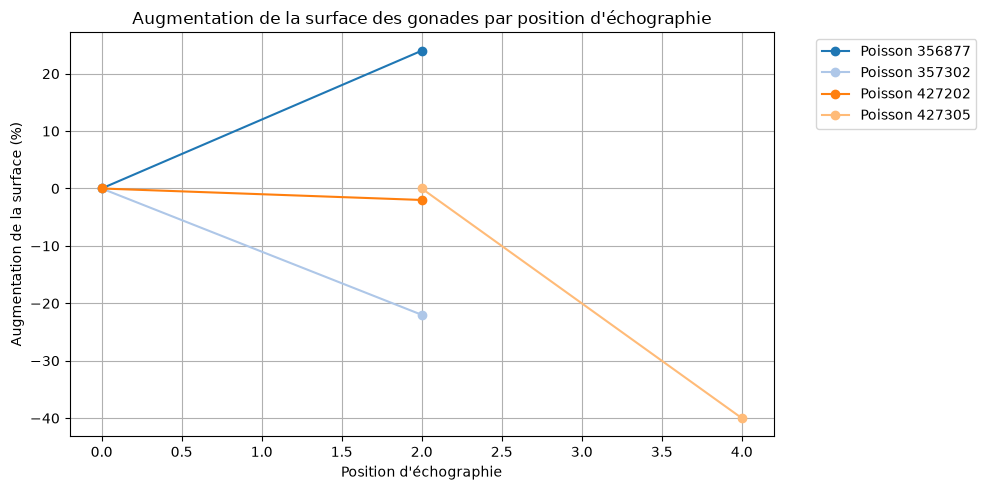

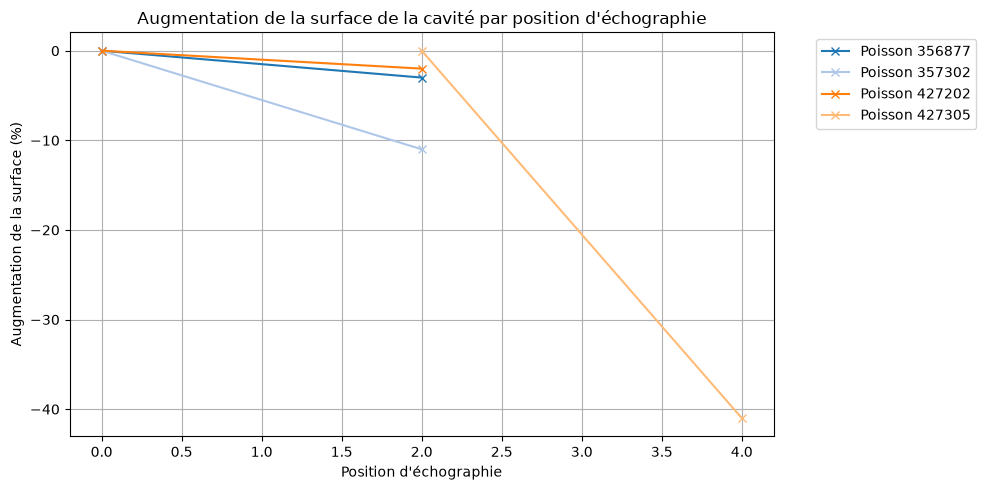

In [73]:
plot_evolution_curves(df_2_lines)

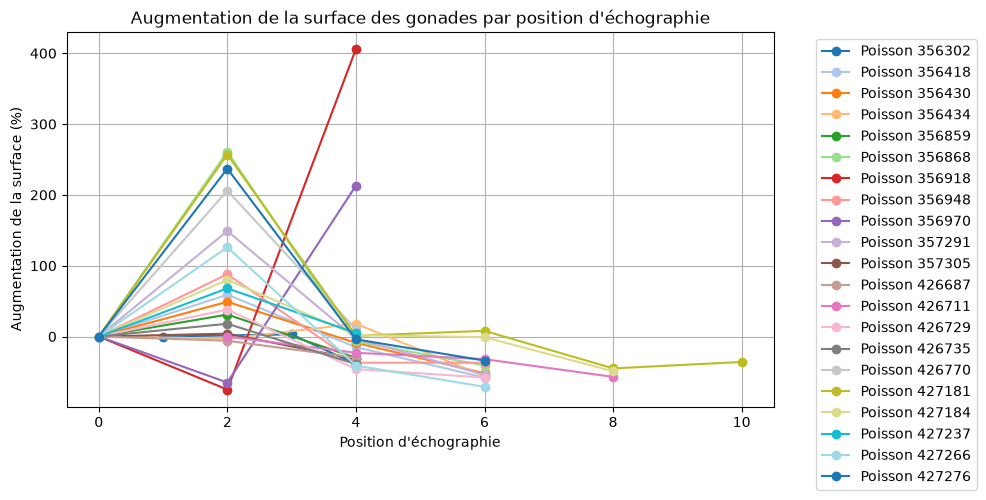

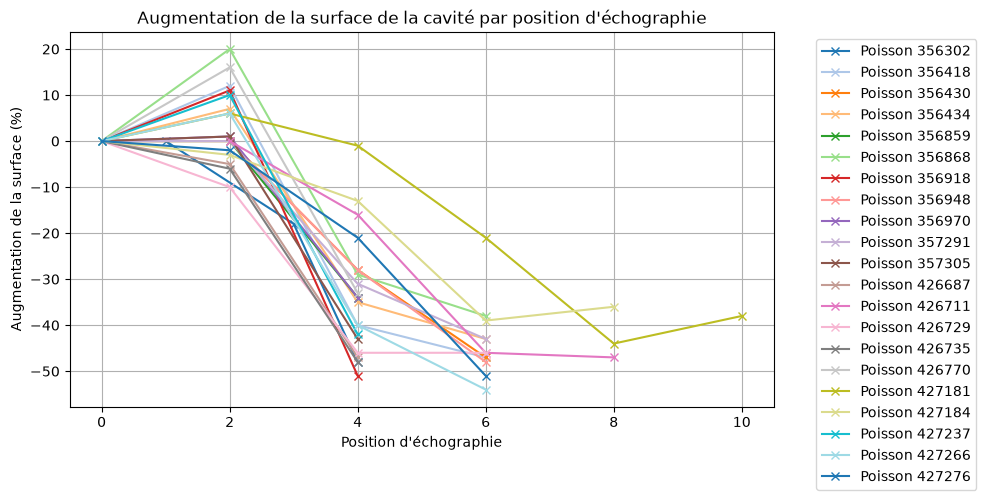

In [74]:
plot_evolution_curves(df_other)

## Graphique pour voir le lien entre la cavité et la gonade

Corrélation : 0.6326842241038433


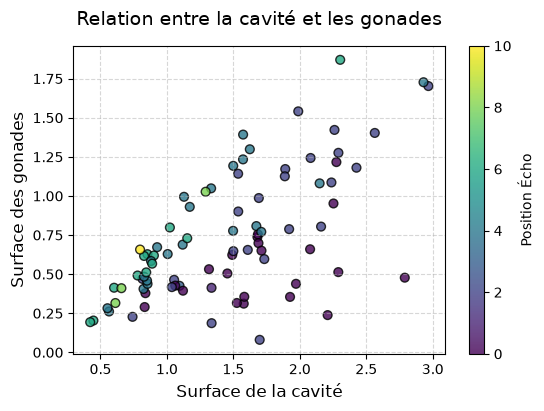

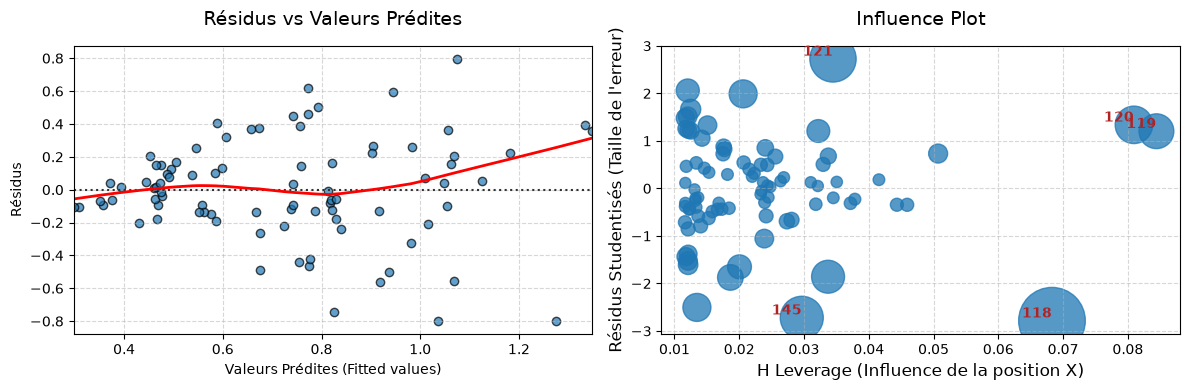

In [75]:
print(f"Corrélation : {df_true_fish.surface_cavite.corr(df_true_fish.surface_gonade)}") # Corrélation

nuage_points(
    x=df_true_fish.surface_cavite, 
    y=df_true_fish.surface_gonade,
    color_var=df_true_fish['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

# Tranformations logarithmiques car non linéaire
linear_regression(df_true_fish.surface_cavite, df_true_fish.surface_gonade)

In [76]:
# On divise en deux les données pour voir si la relation est différente selon la position de l'écho
df_debut = df_true_fish[df_true_fish['position echo'] < 2]
df_fin = df_true_fish[df_true_fish['position echo'] >= 2]

Corrélation : 0.390683731530524


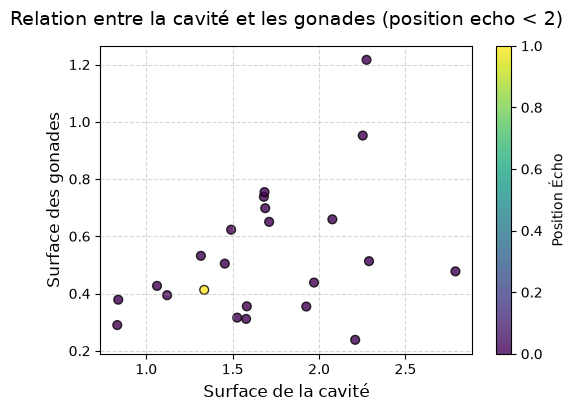

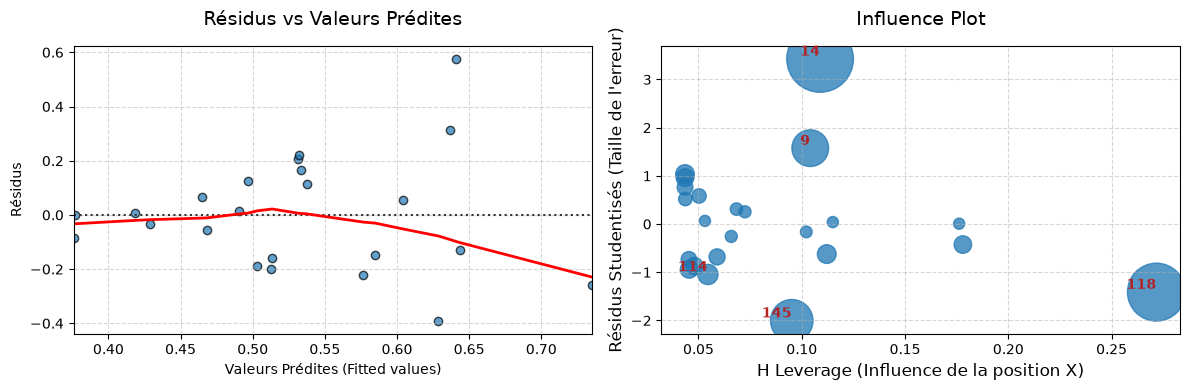

In [82]:
print(f"Corrélation : {df_debut.surface_cavite.corr(df_debut.surface_gonade)}") # Corrélation

nuage_points(
    x=df_debut.surface_cavite, 
    y=df_debut.surface_gonade,
    color_var=df_debut['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades (position echo < 2)", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

# Tranformations logarithmiques car non linéaire
linear_regression(df_debut.surface_cavite, df_debut.surface_gonade)

In [79]:
df_debut.loc[118]

id poisson                        427181
position echo                        0.0
surface_cavite                  2.789467
surface_gonade                  0.477515
volume_cavite                  22.676348
volume_gonade                  13.759359
echelle                              3.8
augmentation_surface_gonade          0.0
augmentation_surface_cavite          0.0
surface_moyenne_oeufs                NaN
volume_moyen_oeufs                   NaN
cap_id                            427181
poids_poisson                      284.5
long_poisson                         295
age_poisson                          NaN
Name: 118, dtype: object

Corrélation : 0.813791639937632


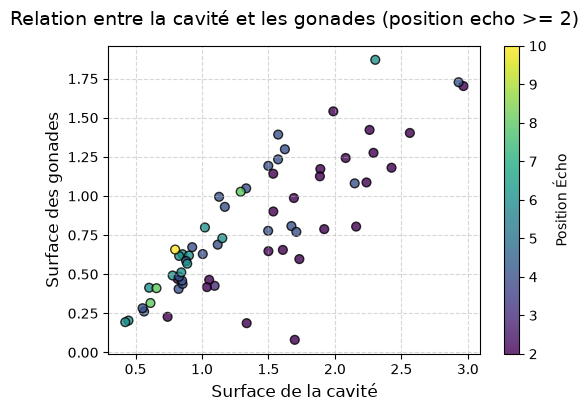

In [80]:
print(f"Corrélation : {df_fin.surface_cavite.corr(df_fin.surface_gonade)}") # Corrélation

nuage_points(
    x=df_fin.surface_cavite, 
    y=df_fin.surface_gonade,
    color_var=df_fin['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre la cavité et les gonades (position echo >= 2)", 
    xlabel="Surface de la cavité", 
    ylabel="Surface des gonades",
    couleur='teal'
    )

### Détection des anomalies

In [83]:
for id in df_true_fish['id poisson'].unique():
    rows = df_true_fish[df_true_fish['id poisson'] == id]
    nb_rows = len(rows)
    pb_list = []

    # Détection des potentiels problèmes de surfaces pour des poissons avec plus de 2 échos
    if nb_rows > 2:
        for i in range(nb_rows):
            # Si l'écho est à Op+2, alors elle ne doit pas avoir une augmentation négative de la surface des gonades
            if rows.iloc[i]["position echo"]==2.0:
                value = rows.iloc[i].augmentation_surface_gonade
                if value < 0 :
                    pb_list.append(1)
                else:
                    pb_list.append(0)

            # Si l'écho est à Op+3 ou plus, alors elle ne doit pas avoir une augmentation de la surface des gonades supérieure à 10%
            elif rows.iloc[i]["position echo"]>2.0:
                value = rows.iloc[i].augmentation_surface_gonade
                if value > 10 :
                    pb_list.append(1)
                else:
                    pb_list.append(0)
            else:
                pb_list.append(0)


        for i in range(len(pb_list)-1):
            # Si il y a deux "1" à la suite, alors l'erreur est sur la première échographie où il y a un "1"
            if pb_list[i] == 1 and pb_list[i+1] == 1:
                print(f"Poisson : {id} - Problèmes : {pb_list}")
                print(f"Poisson : {id} - Problème sur l'écho à la position {rows.iloc[i]['position echo']} (diminution surface gonade : {rows.iloc[i]['augmentation_surface_gonade']})")
                break
        # Si il y a un "1" seul à la deuxième position, alors l'erreur est sur la première échographie
        if pb_list[1] == 1 and pb_list[0] == 0 and pb_list[2] == 0:
            print(f"Poisson : {id} - Problèmes : {pb_list}")
            print(f"Poisson : {id} - Problème sur l'écho à la position {rows.iloc[0]['position echo']} (diminution surface gonade : {rows.iloc[0]['augmentation_surface_gonade']})")

Poisson : 356434 - Problèmes : [0, 1, 1, 0]
Poisson : 356434 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -3.0)
Poisson : 356918 - Problèmes : [0, 1, 1]
Poisson : 356918 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -75.0)
Poisson : 356970 - Problèmes : [0, 1, 1]
Poisson : 356970 - Problème sur l'écho à la position 2.0 (diminution surface gonade : -65.0)
Poisson : 426687 - Problèmes : [0, 1, 0]
Poisson : 426687 - Problème sur l'écho à la position 0.0 (diminution surface gonade : 0.0)


## Graphique pour voir le lien entre la cavité/gonade.oeufs et le poisson taille/poids

### Rapport gonado-somatique : poids gonade / poids poisson * 100

Quantiles GSI: [1.63797078 1.86473025 2.46438445 3.70607036 4.79851148 6.10055405
 6.16901732]


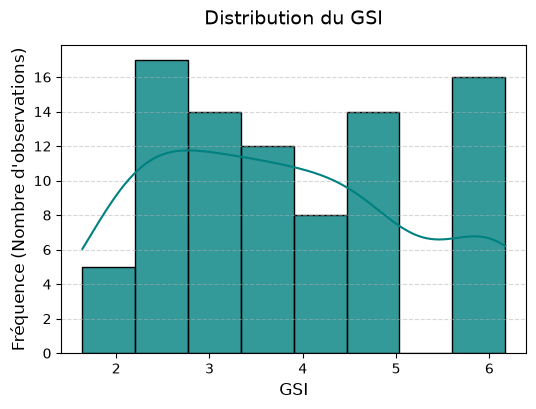

In [86]:
GSI = df_true_fish.volume_gonade / df_true_fish.poids_poisson * 100
print(f"Quantiles GSI: {np.quantile(GSI, q = (0, 0.05, 0.25, 0.5, 0.75, 0.95, 1))}") # Affiche les quantiles du GSI
distribution(GSI, "Distribution du GSI", "GSI", couleur='teal')

### Relation poids/longueur poisson et volume gonade

Corrélation : 0.8258222765120609


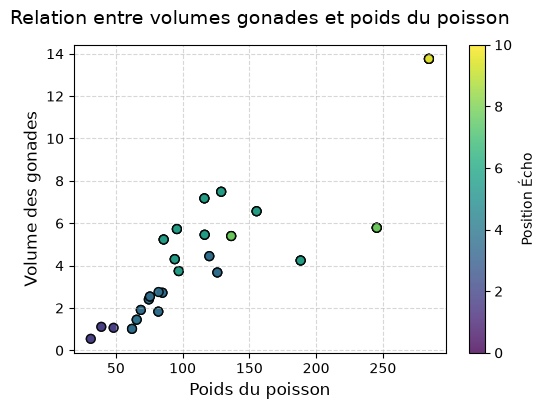

In [98]:
print(f"Corrélation : {df_true_fish.volume_gonade.corr(df_true_fish.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_fish.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_fish.volume_gonade,
    color_var=df_true_fish['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre volumes gonades et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des gonades",
    couleur='teal'
    )

### Relation poids/longueur poisson et volume cavité

Corrélation : 0.9030140414048496


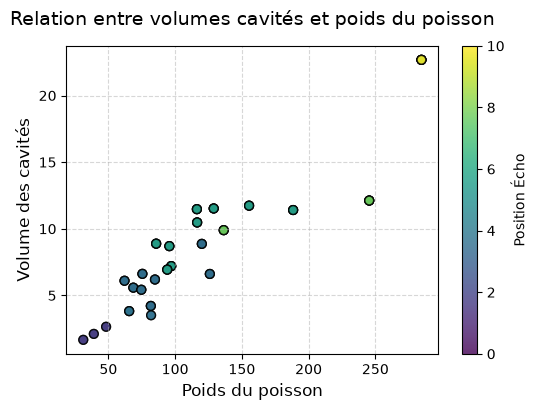

In [100]:
print(f"Corrélation : {df_true_fish.volume_cavite.corr(df_true_fish.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_fish.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_fish.volume_cavite,
    color_var=df_true_fish['position echo'],  # Utilisation de la variable 'position echo' pour colorier les points
    titre="Relation entre volumes cavités et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des cavités",
    couleur='teal'
    )

## Analyse des résultats des oeufs distribution

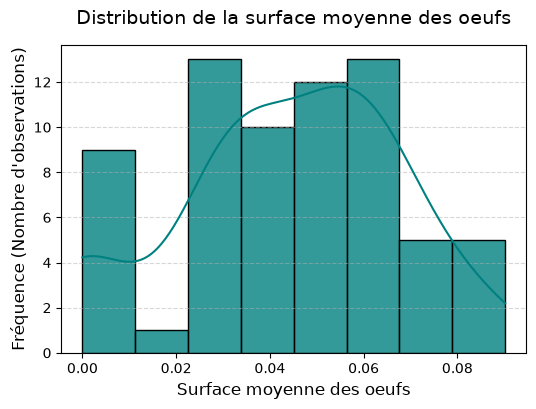

[0.         0.         0.03008234 0.04685062 0.06083462 0.07955068
 0.09019375]


In [46]:
distribution(df_true_eggs.surface_moyenne_oeufs, "Distribution de la surface moyenne des oeufs", "Surface moyenne des oeufs", couleur='teal')
print(np.quantile(df_true_eggs.surface_moyenne_oeufs, q = (0, 0.05, 0.25, 0.5, 0.75, 0.95, 1))) # Affiche les quantiles de la surface moyenne des oeufs

### Relation volume des oeufs et poids/longueur poisson

Corrélation : 0.23547186202548906


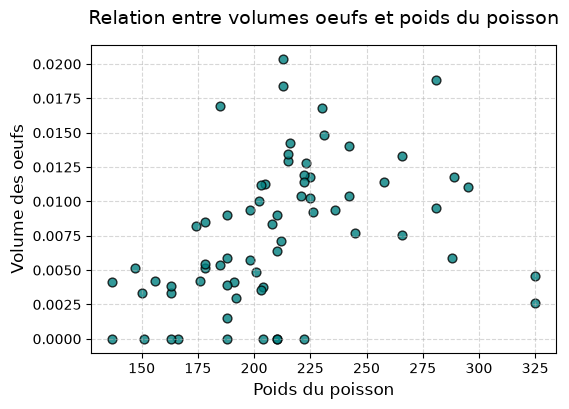

In [ ]:
print(f"Corrélation : {df_true_eggs.volume_moyen_oeufs.corr(df_true_eggs.poids_poisson)}") # Corrélation

nuage_points(
    x=df_true_eggs.poids_poisson, # long_poisson ou poids_poisson
    y=df_true_eggs.volume_moyen_oeufs,
    titre="Relation entre volumes oeufs et poids du poisson", 
    xlabel="Poids du poisson", 
    ylabel="Volume des oeufs",
    couleur='teal'
    )

In [ ]:
df_final = df_res_true[["id poisson", "volume_cavite", "volume_gonade", "echelle", "volume_moyen_oeufs", 
                        "poids_poisson", "long_poisson", "age_poisson"]].groupby('id poisson', as_index=False).last()
df_final = df_final.dropna()

### Relation volume des oeufs et volume/longueur gonade

Corrélation : 0.3719566523936962


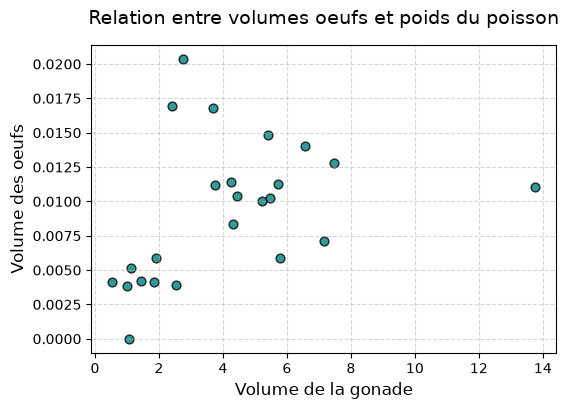

In [118]:
print(f"Corrélation : {df_final.volume_moyen_oeufs.corr(df_final.volume_gonade)}") # Corrélation

nuage_points(
    x=df_final.volume_gonade, # long_poisson ou poids_poisson
    y=df_final.volume_moyen_oeufs,
    titre="Relation entre volumes oeufs et poids du poisson", 
    xlabel="Volume de la gonade", 
    ylabel="Volume des oeufs",
    couleur='teal'
    )

## Masques prédits

### Récupère le volume prédits des gonades de l'échantillon

In [41]:
all_resultats = []

# --- Calcul des volumes par poisson ----
for id in unique_id:
    # On récupère les échographies associées au poisson
    echos_poisson = df[df.cap_id == id]
    
    # Appel de la fonction autonome
    res_poisson = calculate_volumes(echos_poisson, id, "U-NET/masks/3_classes/pred_") # "data/YOLO/labels/" ou "U-NET/masks/3_classes/true_"
    
    # On convertit le dict du poisson en DataFrame et on l'ajoute à la liste globale
    all_resultats.append(pd.DataFrame(res_poisson))

# On fusionne tous les résultats en un seul DataFrame final
df_res = pd.concat(all_resultats, ignore_index=True)
df_res.to_csv("true_volumes_ech.csv", index=False) # Sauvegarde du DataFrame en CSV

Position de l'écho : 0.0, surface gonades : 0.86 cm2, rayon : 0.52 cm, surface cavité : 2.07 cm2
Position de l'écho : 2.0, surface gonades : 0.30 cm2, rayon : 0.31 cm, surface cavité : 2.09 cm2
Position de l'écho : 4.0, surface gonades : 0.92 cm2, rayon : 0.54 cm, surface cavité : 1.40 cm2
Poisson n°: 356970, Nombre d'échos : 3/3, Volume total gonades: 3.05 cm3, volume total cavité: 8.80 cm3
-----------------------
Position de l'écho : 0.0, surface gonades : 1.01 cm2, rayon : 0.57 cm, surface cavité : 2.70 cm2
Position de l'écho : 2.0, surface gonades : 1.40 cm2, rayon : 0.67 cm, surface cavité : 2.45 cm2
Position de l'écho : 4.0, surface gonades : 0.77 cm2, rayon : 0.50 cm, surface cavité : 1.31 cm2
Position de l'écho : 6.0, surface gonades : 0.35 cm2, rayon : 0.33 cm, surface cavité : 0.70 cm2
Poisson n°: 426729, Nombre d'échos : 4/4, Volume total gonades: 5.92 cm3, volume total cavité: 11.41 cm3
-----------------------
Position de l'écho : 2.0, surface gonades : 2.69 cm2, rayon : 0.